# Clase 3 - Practica: Preprocesamiento de Datos
## Inteligencia Artificial - Ingenieria Mecatronica

**Profesor:** Dr. Diego Stalder  
**Auxiliar:** Ing. Enrique Paiva

---

En esta practica vamos a explorar tecnicas de preprocesamiento de datos y su impacto en modelos de regresion.

**Objetivos:**
1. Aprender a manipular datos con Pandas
2. Aplicar normalizacion y estandarizacion
3. Codificar variables categoricas
4. Manejar datos faltantes
5. Medir el impacto del preprocesamiento en regresiones
6. Interpretar metricas de evaluacion

---

## 1. Introduccion a NumPy y Pandas

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configurar visualizacion
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


## 2. Dataset: Ames Housing (Simulado)

Vamos a trabajar con un dataset simulado similar al de Ames Housing para demostrar el impacto del preprocesamiento.

In [35]:
np.random.seed(42)
n = 1000

# Generar datos con relaciones realistas
ames_data = pd.DataFrame({
    'LotArea': np.random.randint(1000, 20000, n),
    'GrLivArea': np.random.randint(400, 5000, n),
    'YearBuilt': np.random.randint(1872, 2010, n),
    'OverallQual': np.random.randint(1, 11, n),
    'TotalBsmtSF': np.random.randint(0, 6000, n),
    'Neighborhood': np.random.choice(['Ames', 'College', 'OldTown', 'Edwards', 'Somerset'], n),
    'MoSold': np.random.randint(1, 13, n),
})

# Crear variable objetivo con relacion realista
ames_data['SalePrice'] = (
    50000 +
    20 * ames_data['GrLivArea'] +
    150 * ames_data['OverallQual'] +
    2 * ames_data['LotArea'] +
    30 * ames_data['YearBuilt'] -
    5 * ames_data['TotalBsmtSF'] +
    np.random.normal(0, 20000, n)
)

# Introducir valores faltantes
ames_data.loc[np.random.choice(n, 150, replace=False), 'LotArea'] = np.nan
ames_data.loc[np.random.choice(n, 80, replace=False), 'GrLivArea'] = np.nan
ames_data.loc[np.random.choice(n, 50, replace=False), 'OverallQual'] = np.nan

print("Dataset creado - Dimensiones:", ames_data.shape)
print("\nValores faltantes:")
print(ames_data.isnull().sum())
print("\nPrimeras filas:")
ames_data.head()

Dataset creado - Dimensiones: (1000, 8)

Valores faltantes:
LotArea         150
GrLivArea        80
YearBuilt         0
OverallQual      50
TotalBsmtSF       0
Neighborhood      0
MoSold            0
SalePrice         0
dtype: int64

Primeras filas:


,LotArea,GrLivArea,YearBuilt,OverallQual,TotalBsmtSF,Neighborhood,MoSold,SalePrice
0,16795.0,3479.0,2009,3.0,3327,OldTown,12,187355.690393
1,1860.0,1232.0,1929,9.0,5630,Edwards,4,99478.550034
2,6390.0,4808.0,1991,3.0,5192,OldTown,8,216153.440378
3,12964.0,3206.0,2004,6.0,4274,Ames,2,185629.538771
4,NaN,2890.0,1936,1.0,2259,College,10,204656.030224


## 3. Impacto del Preprocesamiento en Regresion

Vamos a comparar el rendimiento de diferentes modelos de regresion con y sin preprocesamiento.

In [36]:
# Separar features y target
X = ames_data.drop('SalePrice', axis=1)
y = ames_data['SalePrice']

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 800, Test size: 200


### 3.1. Modelo SIN Preprocesamiento (Baseline)

Primero, entrenamos un modelo sin ningun preprocesamiento.

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Función para evaluar modelos
def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre="Modelo"):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"=== {nombre} ===")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2: {r2:.4f}")
    print()
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'pred': y_pred}

# Modelo baseline: imputacion manual + codificacion simple, sin escalamiento
X_train_baseline = X_train.copy()
X_test_baseline = X_test.copy()

# Imputar numericas y categoricas
def obtener_imputacion_baseline(X_train, X_test, cat_cols):
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    num_cols = np.size(X_train_copy.select_dtypes(include=[np.number]).columns)
    for col in num_cols:
        mediana = X_train_copy[col].median()
        X_train_copy[col] = X_train_copy[col].fillna(mediana)
        X_test_copy[col] = X_test_copy[col].fillna(mediana)

    for col in cat_cols:
        moda = X_train_copy[col].mode()[0]
        X_train_copy[col] = X_train_copy[col].fillna(moda)
        X_test_copy[col] = X_test_copy[col].fillna(moda)

    return X_train_copy, X_test_copy

def obtener_imputacion_baseline(X_train, X_test, cat_cols):
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    num_cols = X_train_copy.select_dtypes(include=[np.number]).columns

    for col in num_cols:
        mediana = X_train_copy[col].median()
        X_train_copy[col] = X_train_copy[col].fillna(mediana)
        X_test_copy[col] = X_test_copy[col].fillna(mediana)

    for col in cat_cols:
        moda = X_train_copy[col].mode()[0]
        X_train_copy[col] = X_train_copy[col].fillna(moda)
        X_test_copy[col] = X_test_copy[col].fillna(moda)

    return X_train_copy, X_test_copy

# One-hot encoding manual para el baseline
X_train_baseline = pd.get_dummies(X_train_baseline, columns=['Neighborhood'], drop_first=True)
X_test_baseline = pd.get_dummies(X_test_baseline, columns=['Neighborhood'], drop_first=True)
X_test_baseline = X_test_baseline.reindex(columns=X_train_baseline.columns, fill_value=0)

lr_baseline = LinearRegression()
# Impute missing values in baseline data
X_train_baseline[['LotArea', 'GrLivArea', 'OverallQual']] = X_train_baseline[['LotArea', 'GrLivArea', 'OverallQual']].fillna(X_train_baseline[['LotArea', 'GrLivArea', 'OverallQual']].median())
X_test_baseline[['LotArea', 'GrLivArea', 'OverallQual']] = X_test_baseline[['LotArea', 'GrLivArea', 'OverallQual']].fillna(X_train_baseline[['LotArea', 'GrLivArea', 'OverallQual']].median())

# Convert boolean columns to int for the model
X_train_baseline = X_train_baseline.astype(int)
X_test_baseline = X_test_baseline.astype(int)

resultados_baseline = evaluar_modelo(
    lr_baseline,
    X_train_baseline,
    X_test_baseline,
    y_train,
    y_test,
    "Regresion Lineal - BASELINE (sin escalamiento)"
)


=== Regresion Lineal - BASELINE (sin escalamiento) ===
RMSE: 19537.76
MAE: 15353.13
R2: 0.7121



In [38]:
# Ver los coeficientes del modelo sin preprocesamiento
coef_baseline = pd.DataFrame({
    'Variable': X_train_baseline.columns,
    'Coeficiente': lr_baseline.coef_.ravel()
})
print("Coeficientes del modelo SIN preprocesamiento:")
print(coef_baseline)

Coeficientes del modelo SIN preprocesamiento:
                Variable  Coeficiente
0                LotArea     1.863218
1              GrLivArea    19.134095
2              YearBuilt    37.950219
3            OverallQual   225.463898
4            TotalBsmtSF    -5.131064
5                 MoSold  -271.011215
6   Neighborhood_College -1629.567951
7   Neighborhood_Edwards -1493.582202
8   Neighborhood_OldTown  2097.879235
9  Neighborhood_Somerset   861.412043


### 3.2. Modelo CON Preprocesamiento (Escalamiento + Codificacion + Imputacion)

Ahora aplicamos un pipeline completo de preprocesamiento.

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Definir columnas
num_cols = ['LotArea', 'GrLivArea', 'YearBuilt', 'OverallQual', 'TotalBsmtSF']
cat_cols = ['Neighborhood']
cyclic_cols = ['MoSold']

# Preprocesador
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False))
    ]), cat_cols),
    ('cyclic', 'passthrough', cyclic_cols)
])

# Crear pipeline completo
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entrenar y evaluar
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Regresion Lineal CON Preprocesamiento ===")
print(f"RMSE: {rmse_lr:.2f}")
print(f"MAE: {mae_lr:.2f}")
print(f"R2: {r2_lr:.4f}")

=== Regresion Lineal CON Preprocesamiento ===
RMSE: 19537.76
MAE: 15353.13
R2: 0.7121


In [40]:
# Comparacion de resultados
print("\n=== COMPARACION ===")
print(f"RMSE: Baseline {resultados_baseline['rmse']:.2f} -> Con Preprocesamiento {rmse_lr:.2f}")
print(f"Mejora RMSE: {(1 - rmse_lr/resultados_baseline['rmse'])*100:.1f}%")
print(f"\nR2: Baseline {resultados_baseline['r2']:.4f} -> Con Preprocesamiento {r2_lr:.4f}")
print(f"Mejora R2: {(r2_lr - resultados_baseline['r2'])*100:.1f}%")


=== COMPARACION ===
RMSE: Baseline 19537.76 -> Con Preprocesamiento 19537.76
Mejora RMSE: -0.0%

R2: Baseline 0.7121 -> Con Preprocesamiento 0.7121
Mejora R2: -0.0%


### 3.3. Visualizacion de la Mejora

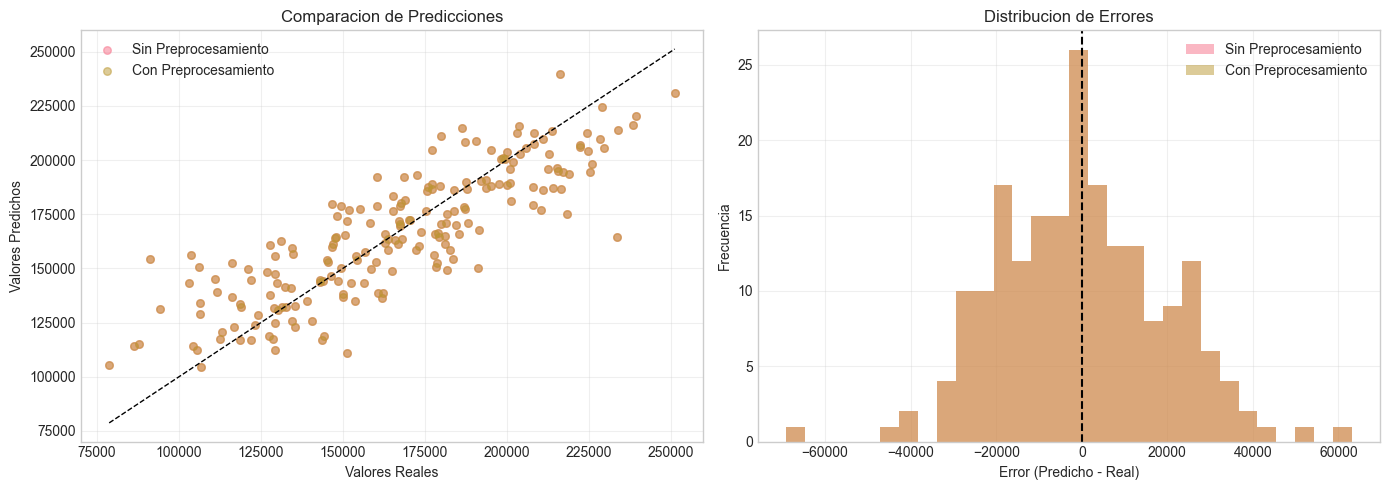

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Valores reales vs predichos
ax1 = axes[0]
ax1.scatter(y_test, resultados_baseline['pred'], alpha=0.5, label='Sin Preprocesamiento', s=30)
ax1.scatter(y_test, y_pred_lr, alpha=0.5, label='Con Preprocesamiento', s=30)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
ax1.set_xlabel('Valores Reales')
ax1.set_ylabel('Valores Predichos')
ax1.set_title('Comparacion de Predicciones')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Grafico 2: Distribucion de errores
ax2 = axes[1]
errores_baseline = resultados_baseline['pred'] - y_test
errores_lr = y_pred_lr - y_test
ax2.hist(errores_baseline, bins=30, alpha=0.5, label='Sin Preprocesamiento')
ax2.hist(errores_lr, bins=30, alpha=0.5, label='Con Preprocesamiento')
ax2.axvline(0, color='k', linestyle='--')
ax2.set_xlabel('Error (Predicho - Real)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribucion de Errores')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Comparacion de Tecnicas de Escalamiento

In [42]:
# Funcion para evaluar diferentes escaladores
def evaluar_escalador(escalador, nombre):
    pipeline = Pipeline([
        ('preprocessor', ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', escalador)
            ]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(drop='first', sparse_output=False))
            ]), cat_cols),
            ('cyclic', 'passthrough', cyclic_cols)
        ])),
        ('regressor', LinearRegression())
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return rmse, r2

# Probar diferentes escaladores
escaladores = {
    'Sin Escalar': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
}

resultados_escalado = {}
for nombre, escalador in escaladores.items():
    if escalador is None:
        # Sin escalado (solo imputacion)
        pipeline = Pipeline([
            ('preprocessor', ColumnTransformer([
                ('num', SimpleImputer(strategy='median'), num_cols),
                ('cat', Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
                ]), cat_cols),
                ('cyclic', 'passthrough', cyclic_cols)
            ])),
            ('regressor', LinearRegression())
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
    else:
        rmse, r2 = evaluar_escalador(escalador, nombre)
    
    resultados_escalado[nombre] = {'rmse': rmse, 'r2': r2}
    print(f"{nombre}: RMSE={rmse:.2f}, R2={r2:.4f}")

Sin Escalar: RMSE=19537.76, R2=0.7121
StandardScaler: RMSE=19537.76, R2=0.7121
MinMaxScaler: RMSE=19537.76, R2=0.7121


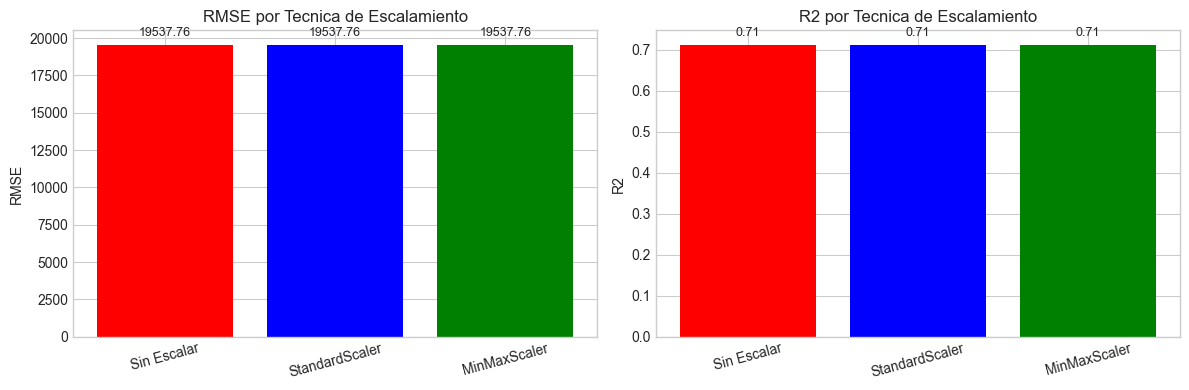

In [43]:
# Visualizar comparacion de escaladores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

nombres = list(resultados_escalado.keys())
rmse_values = [resultados_escalado[n]['rmse'] for n in nombres]
r2_values = [resultados_escalado[n]['r2'] for n in nombres]

ax1 = axes[0]
bars1 = ax1.bar(nombres, rmse_values, color=['red', 'blue', 'green'])
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE por Tecnica de Escalamiento')
ax1.tick_params(axis='x', rotation=15)

ax2 = axes[1]
bars2 = ax2.bar(nombres, r2_values, color=['red', 'blue', 'green'])
ax2.set_ylabel('R2')
ax2.set_title('R2 por Tecnica de Escalamiento')
ax2.tick_params(axis='x', rotation=15)

for ax, bars in [(ax1, bars1), (ax2, bars2)]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02 * height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Impacto del Escalamiento en Coeficientes

El escalamiento afecta la magnitud e interpretacion de los coeficientes.

In [44]:
# Comparar coeficientes con y sin escalamiento
def obtener_coeficientes_con_escalado(escalador, nombre):
    if escalador is None:
        # Sin escalado
        preprocessor = ColumnTransformer([
            ('num', SimpleImputer(strategy='median'), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(drop='first', sparse_output=False))
            ]), cat_cols),
            ('cyclic', 'passthrough', cyclic_cols)
        ])
        X_processed = preprocessor.fit_transform(X_train)
        model = LinearRegression().fit(X_processed, y_train)
        return model.coef_
    else:
        preprocessor = ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', escalador)
            ]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(drop='first', sparse_output=False))
            ]), cat_cols),
            ('cyclic', 'passthrough', cyclic_cols)
        ])
        X_processed = preprocessor.fit_transform(X_train)
        model = LinearRegression().fit(X_processed, y_train)
        return model.coef_

# Obtener coeficientes
coef_sin_escalar = obtener_coeficientes_con_escalado(None, 'Sin Escalar')
coef_standard = obtener_coeficientes_con_escalado(StandardScaler(), 'StandardScaler')
coef_minmax = obtener_coeficientes_con_escalado(MinMaxScaler(), 'MinMaxScaler')

# Crear DataFrame para comparar
nombres_cat = pd.get_dummies(X_train['Neighborhood'], prefix='Neighborhood', drop_first=True).columns.tolist()
nombres_vars = num_cols + nombres_cat + cyclic_cols
comparacion_coef = pd.DataFrame({
    'Variable': nombres_vars,
    'Sin Escalar': coef_sin_escalar[:len(nombres_vars)],
    'StandardScaler': coef_standard[:len(nombres_vars)],
    'MinMaxScaler': coef_minmax[:len(nombres_vars)]
})

print("Comparacion de Coeficientes:")
comparacion_coef.head(10)

Comparacion de Coeficientes:


,Variable,Sin Escalar,StandardScaler,MinMaxScaler
0,LotArea,1.863218,9337.774313,35276.315493
1,GrLivArea,19.134095,24471.763473,87710.690974
2,YearBuilt,37.950219,1535.111455,5199.180012
3,OverallQual,225.463898,626.242909,2029.175080
4,TotalBsmtSF,-5.131064,-8918.997063,-30704.285816
5,Neighborhood_College,-1629.567951,-1629.567951,-1629.567951
6,Neighborhood_Edwards,-1493.582202,-1493.582202,-1493.582202
7,Neighborhood_OldTown,2097.879235,2097.879235,2097.879235
8,Neighborhood_Somerset,861.412043,861.412043,861.412043
9,MoSold,-271.011215,-271.011215,-271.011215


## 6. Regresion con Regularizacion (Ridge y Lasso)

El escalamiento es CRITICO para modelos regularizados.

In [45]:
from sklearn.linear_model import Ridge, Lasso

# Evaluar diferentes modelos con preprocesamiento
modelos = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01)
}

resultados_modelos = {}

for nombre, modelo in modelos.items():
    pipeline = Pipeline([
        ('preprocessor', ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(drop='first', sparse_output=False))
            ]), cat_cols),
            ('cyclic', 'passthrough', cyclic_cols)
        ])),
        ('regressor', modelo)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    resultados_modelos[nombre] = {'rmse': rmse, 'r2': r2}
    print(f"{nombre}: RMSE={rmse:.2f}, R2={r2:.4f}")

LinearRegression: RMSE=19537.76, R2=0.7121
Ridge: RMSE=19539.98, R2=0.7120
Lasso: RMSE=19537.76, R2=0.7121


In [ ]:
# Comparar modelos sin preprocesamiento (solo para ver la diferencia)
print("\n=== MODELOS SIN PREPROCESAMIENTO ===")
for nombre, modelo in modelos.items():
    def preparar_sin_preprocesamiento(X_train, X_test=None):
        X_train_proc = X_train.copy()
        X_test_proc = X_test.copy() if X_test is not None else None

        num_cols = X_train_proc.select_dtypes(include=[np.number]).columns

        for col in num_cols:
            mediana = X_train_proc[col].median()
            X_train_proc[col] = X_train_proc[col].fillna(mediana)
            if X_test_proc is not None:
                X_test_proc[col] = X_test_proc[col].fillna(mediana)

        moda = X_train_proc["Neighborhood"].mode()[0]
        X_train_proc["Neighborhood"] = X_train_proc["Neighborhood"].fillna(moda)
        if X_test_proc is not None:
            X_test_proc["Neighborhood"] = X_test_proc["Neighborhood"].fillna(moda)

        X_train_proc = pd.get_dummies(
            X_train_proc, columns=["Neighborhood"], drop_first=True
        ).astype(float)

        if X_test_proc is not None:
            X_test_proc = pd.get_dummies(
                X_test_proc, columns=["Neighborhood"], drop_first=True
            ).astype(float)
            X_test_proc = X_test_proc.reindex(columns=X_train_proc.columns, fill_value=0)
            return X_train_proc, X_test_proc

        return X_train_proc


    print("\n=== MODELOS SIN PREPROCESAMIENTO ===")
    X_train_proc, X_test_proc = preparar_sin_preprocesamiento(X_train, X_test)

    for nombre, modelo in modelos.items():
        modelo.fit(X_train_proc, y_train)
        y_pred = modelo.predict(X_test_proc)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        print(f"{nombre} (sin prep): RMSE={rmse:.2f}, R2={r2:.4f}")
    y_pred = modelo.predict(X_test_proc)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"{nombre} (sin prep): RMSE={rmse:.2f}, R2={r2:.4f}")


=== MODELOS SIN PREPROCESAMIENTO ===

=== MODELOS SIN PREPROCESAMIENTO ===
LinearRegression (sin prep): RMSE=19537.76, R2=0.7121
Ridge (sin prep): RMSE=19537.15, R2=0.7121
Lasso (sin prep): RMSE=19537.76, R2=0.7121


TypeError: Cannot convert [['OldTown' 'OldTown' 'College' 'OldTown' 'Ames' 'Ames' 'College'
  'Edwards' 'Somerset' 'Somerset' 'Ames' 'Edwards' 'Somerset' 'Ames'
  'Ames' 'Edwards' 'Somerset' 'OldTown' 'Ames' 'College' 'Edwards'
  'Edwards' 'Edwards' 'Ames' 'OldTown' 'Edwards' 'Ames' 'College'
  'Somerset' 'Ames' 'OldTown' 'Edwards' 'Somerset' 'OldTown' 'Somerset'
  'Ames' 'Edwards' 'College' 'Ames' 'College' 'College' 'College'
  'Edwards' 'OldTown' 'Ames' 'College' 'College' 'OldTown' 'Somerset'
  'Ames' 'Ames' 'Ames' 'OldTown' 'College' 'Edwards' 'OldTown' 'OldTown'
  'Edwards' 'Edwards' 'College' 'OldTown' 'OldTown' 'OldTown' 'College'
  'OldTown' 'College' 'College' 'OldTown' 'OldTown' 'OldTown' 'Edwards'
  'Edwards' 'Ames' 'Ames' 'College' 'Ames' 'Ames' 'OldTown' 'OldTown'
  'Ames' 'Somerset' 'Ames' 'Somerset' 'OldTown' 'OldTown' 'Ames'
  'College' 'College' 'Ames' 'College' 'OldTown' 'Ames' 'Somerset'
  'OldTown' 'Somerset' 'Ames' 'Ames' 'Edwards' 'Ames' 'OldTown' 'Ames'
  'Edwar

## 7. Dataset: Titanic - Regresion Logistica

Ahora aplicamos el preprocesamiento a un problema de clasificacion con Regresion Logistica.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Cargar datos
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

# Seleccionar features
titanic_X = titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
titanic_y = titanic['Survived']

# Dividir
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    titanic_X, titanic_y, test_size=0.2, random_state=42
)

print("Titanic - Dimensiones:", titanic_X.shape)

In [ ]:
# Definir preprocesador para Titanic
num_cols_t = ['Age', 'Fare']
cat_cols_t = ['Sex', 'Embarked']
ord_cols_t = ['Pclass', 'SibSp', 'Parch']

preprocessor_titanic = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols_t),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False))
    ]), cat_cols_t),
    ('ord', 'passthrough', ord_cols_t)
])

# Pipeline completo
pipeline_logreg = Pipeline([
    ('preprocessor', preprocessor_titanic),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Entrenar y evaluar
pipeline_logreg.fit(X_train_t, y_train_t)
y_pred_t = pipeline_logreg.predict(X_test_t)

print("=== REGRESION LOGISTICA - TITANIC ===")
print(f"Accuracy: {accuracy_score(y_test_t, y_pred_t):.4f}")
print(f"Precision: {precision_score(y_test_t, y_pred_t):.4f}")
print(f"Recall: {recall_score(y_test_t, y_pred_t):.4f}")
print(f"F1-Score: {f1_score(y_test_t, y_pred_t):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_t, y_pred_t))
print("\nMatriz de Confusion:")
print(confusion_matrix(y_test_t, y_pred_t))

In [ ]:
# Comparar con modelo sin preprocesamiento
print("=== REGRESION LOGISTICA SIN PREPROCESAMIENTO ===")

# Imputar con mediana/moda simple
X_train_simple = X_train_t.copy()
X_test_simple = X_test_t.copy()

# Imputar numericas
X_train_simple['Age'] = X_train_simple['Age'].fillna(X_train_simple['Age'].median())
X_test_simple['Age'] = X_test_simple['Age'].fillna(X_train_simple['Age'].median())
X_train_simple['Fare'] = X_train_simple['Fare'].fillna(X_train_simple['Fare'].median())
X_test_simple['Fare'] = X_test_simple['Fare'].fillna(X_train_simple['Fare'].median())

# Imputar categoricas
X_train_simple['Embarked'] = X_train_simple['Embarked'].fillna(X_train_simple['Embarked'].mode()[0])
X_test_simple['Embarked'] = X_test_simple['Embarked'].fillna(X_train_simple['Embarked'].mode()[0])

# One-Hot Encoding manual
X_train_simple = pd.get_dummies(X_train_simple, columns=['Sex', 'Embarked'], drop_first=True)
X_test_simple = pd.get_dummies(X_test_simple, columns=['Sex', 'Embarked'], drop_first=True)

# Entrenar
lr_simple = LogisticRegression(max_iter=1000)
lr_simple.fit(X_train_simple, y_train_t)
y_pred_simple = lr_simple.predict(X_test_simple)

print(f"Accuracy: {accuracy_score(y_test_t, y_pred_simple):.4f}")
print(f"F1-Score: {f1_score(y_test_t, y_pred_simple):.4f}")

## 8. Resumen de Metricas de Evaluacion

### Para Regresion:
- **RMSE (Root Mean Squared Error)**: Sensible a outliers, en unidades de y
- **MAE (Mean Absolute Error)**: Robusto, en unidades de y
- **R2 (Coeficiente de Determinacion)**: Proporcion de varianza explicada (0-1)

### Para Clasificacion:
- **Accuracy**: Proporcion de predicciones correctas
- **Precision**: Exactitud de las predicciones positivas
- **Recall**: Capacidad de encontrar positivos
- **F1-Score**: Media armonica de Precision y Recall

In [ ]:
# Resumen de todos los resultados
print("\n=== RESUMEN DE RESULTADOS ===\n")

print("AMS HOUSING - REGRESION:")
print(f"  Baseline (sin prep): RMSE={resultados_baseline['rmse']:.2f}, R2={resultados_baseline['r2']:.4f}")
print(f"  Con Preprocesamiento: RMSE={rmse_lr:.2f}, R2={r2_lr:.4f}")
print(f"  Mejora: RMSE {(1 - rmse_lr/resultados_baseline['rmse'])*100:.1f}%, R2 {(r2_lr - resultados_baseline['r2'])*100:.1f}%")

print("\nTITANIC - CLASIFICACION:")
print(f"  Con Preprocesamiento: Accuracy={accuracy_score(y_test_t, y_pred_t):.4f}")
print(f"  Sin Preprocesamiento: Accuracy={accuracy_score(y_test_t, y_pred_simple):.4f}")
print(f"  Mejora: {(accuracy_score(y_test_t, y_pred_t) - accuracy_score(y_test_t, y_pred_simple))*100:.1f}%")

## 9. Ejercicios Finales

### Ejercicio 1: Tuning de Regularizacion

Prueba diferentes valores de alpha para Ridge y Lasso, y observa como cambian los coeficientes.

In [ ]:
# [COMPLETAR] Tu codigo aqui
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# ...

### Ejercicio 2: Transformacion de Target

Aplica transformacion logaritmica a la variable objetivo (SalePrice) y compara los resultados.

In [ ]:
# [COMPLETAR] Tu codigo aqui
# ...

### Ejercicio 3: Validacion Cruzada

Usa cross_val_score para evaluar el pipeline con y sin preprocesamiento.

In [ ]:
# [COMPLETAR] Tu codigo aqui
# ...

---

## Resumen de Tecnicas de Preprocesamiento

| **Tecnica** | **Cuando usar** | **Scikit-learn** |
|-------------|-----------------|------------------|
| Estandarizacion | Modelos basados en distancia, regularizacion | `StandardScaler` |
| Normalizacion | Redes Neuronales | `MinMaxScaler` |
| One-Hot Encoding | Categoricas nominales | `OneHotEncoder` |
| Label Encoding | Categoricas ordinales | `LabelEncoder` |
| Imputacion | Datos faltantes | `SimpleImputer` |
| Transformacion Log | Target sesgado | `FunctionTransformer` |

---

*Material preparado para la clase del 29 de julio de 2026*